Nadaraya-Watson核回归

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

生成数据集

In [2]:
n_train = 50  # 50个训练样本
x_train, _ = torch.sort(torch.rand(n_train) * 5)  # 训练集

# 真实函数
def f(x):  
    return 2 * torch.sin(x) + x ** 0.8 

# 真实值 + 高斯噪声
y_train = f(x_train) + torch.normal(0.0, 0.5, (n_train,))

# 测试集
x_test = torch.arange(0, 5, 0.1)

y_truth = f(x_test)

n_test = len(x_test)

非参数注意力汇聚

In [ ]:
# 将x_test每个数字重复50遍得到(2500,),然后reshape成(50, 50)
X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train))
# 通过广播机制，计算负欧氏距离 / 2 得到高斯核的指数部分，然后对每一行进行softmax归一化，得到每一个query与每一个key的注意力权重
attention_weights = nn.functional.softmax(-(X_repeat - x_train)**2 / 2, dim=1)
# 最后通过matmul进行矩阵乘法，(50, 50) * (50, ) -> (50, ) 得到每个y_train上对于query的预测值
y_hat = torch.matmul(attention_weights, y_train)

注意力权重

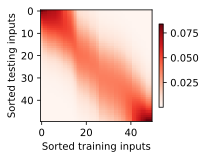

In [4]:
# unsqueeze(0)在原有张量前添加一个维度
d2l.show_heatmaps(attention_weights.unsqueeze(0).unsqueeze(0), xlabel='Sorted training inputs', ylabel='Sorted testing inputs')

### 带参数注意力汇聚  
假定两个张量的形状分别是（n, a, b）和（n, b, c）,它们的批量矩阵乘法输出的形状为（n, a, c）

In [5]:
X = torch.ones(2, 1, 4)
Y = torch.ones(2, 4, 6)
torch.bmm(X, Y).shape

torch.Size([2, 1, 6])

带参数的注意力汇聚

In [ ]:
# w控制的是高斯核的平滑程度
class NWKernelRegression(nn.Module):
    def __init__(self, **kwargs):
        super().__init__( **kwargs)
        self.w = nn.Parameter(torch.rand((1,), requires_grad=True))

    def forward(self, queries, keys, values):
        queries = queries.repeat_interleave(keys.shape[1]).reshape(-1, keys.shape[1])
        self.attention_weight = nn.functional.max(-((queries - keys)*self.w)**2 / 2, dim=1)
        return torch.bmm(self.attention_weight.unsqueeze(1), values.unsqueeze(-1)).reshape(-1)